In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

In [2]:
"""
Major surface scatter class
"""
class SurfaceScatter(object):
    def __init__(self, eps=None, ks=None, theta=None, kl=None, mv=None, C_hh=None, C_vv=None, C_hv=None, D_hh=None, D_vv=None, D_hv=None, **kwargs):
        self.eps = eps
        self.ks = ks
        self.theta = theta
        self.kl = kl

        self.mv = mv
        self.C_hh = C_hh
        self.C_vv = C_vv
        self.D_hh = D_hh
        self.D_vv = D_vv
        self.C_hv = C_hv
        self.D_hv = D_hv

        self._check()

    def _check(self):
        pass
        # assert isinstance(self.eps, complex)

In [3]:
"""
This module implements the Oh et al. (2004)
empirical surface backscattering model as documented
in Ulaby et al (2014), chapter 10.5

References
----------
Oh (2004): Quantitative retrieval of soil moisture content and surface roughness from multipolarized radar observations of bare soil surface. IEEE TGRS 42(3). 596-601.
"""


class Oh04(SurfaceScatter):
    def __init__(self, mv, ks, theta):
        """
        Parameters
        ----------
        mv : float, ndarray
            volumetric soil moisture m3/m3
        ks : float
            product of wavenumber and rms height
            be aware that both need to have the same units
        theta : float, ndarray
            incidence angle [rad]
        """
        super(Oh04, self).__init__(mv=mv, ks=ks, theta=theta)

        # calculate p and q
        self._calc_p()
        self._calc_q()

        # calculate backascatter
        self.vh = self._calc_vh()
        # difference between hv and vh?
        self.vv = self.vh / self.q
        self.hh = self.vh / self.q * self.p

    def get_sim(self):
        return self.vh, self.vv, self.hh

    def _to_dB(self, linear):
        return 10*np.log10(linear)

    def _calc_p(self):
        self.p = 1 - (2.*self.theta/np.pi)**(0.35*self.mv**(-0.65)) * np.exp(-0.4 * self.ks**1.4)

    def _calc_q(self):
        self.q = 0.095 * (0.13 + np.sin(1.5*self.theta))**1.4 * (1-np.exp(-1.3 * self.ks**0.9))

    def _calc_vh(self):
        a = 0.11 * self.mv**0.7 * np.cos(self.theta)**2.2
        b = 1 - np.exp(-0.32 * self.ks**1.8)
        return a*b

    def plot(self, ptype='mv'):
        f = plt.figure()
        ax = f.add_subplot(111)

        if ptype == 'mv':
          x = self.mv
          ax.set_xlabel('volumetric soil moisture [m^3/m^3]')
        elif ptype == 'ks':
          x = self.ks
          ax.set_xlabel('rms height [m]')
        elif ptype == 'theta':
          x = np.rad2deg(self.theta)
          ax.set_xlabel('incidence angle [deg]')
        else:
          raise ValueError('Unknown parameter type')

        ax.plot(x, 10.*np.log10(self.hh), color='blue', label='hh')
        ax.plot(x, 10.*np.log10(self.vv), color='red', label='vv')
        ax.plot(x, 10.*np.log10(self.vh), color='green', label='vh')
        ax.grid()
        #ax.set_ylim(-25.,0.)
        #ax.set_xlim(0.,70.)
        ax.legend()
        # ax.set_xlabel('incidence angle [deg]')
        ax.set_ylabel('backscatter [dB]')

In [4]:
def read_risma_bulk_csv(fname, station, S1_lot='18:30'):

    df = pd.read_csv(fname, header=None, low_memory=False)
    df = df.drop(index=[0,1,2,3,5])
    df = df.reset_index(drop=True)
    df[0] = pd.to_datetime(df[0], format='%Y-%m-%d %H:%M:%S')

    # Set the datetime column as the index
    df.set_index(df.columns[0], inplace=True)

    df.columns = df.iloc[0]
    df = df.iloc[1:]

    # remove first part of the columns name
    df.columns = [col.split('.')[1] for col in df.columns]

    # create a date object from 18:30
    overpass_time = datetime.strptime(S1_lot, '%H:%M')
    oh_bf_overpass_time = overpass_time - timedelta(hours=1)
    oh_af_overpass_time = overpass_time + timedelta(hours=1)

    # Keep rows around -1 and +1 overpass_time based on time index in the df
    df = df[(df.index.time >= oh_bf_overpass_time.time()) & (df.index.time <= oh_af_overpass_time.time())]

    # filter df's columns contain 'Soil water content'
    df = df[[col for col in df.columns if 'Soil water content' in col]]

    # Convert the soil moisture columns to numeric, handling non-numeric values
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # 'coerce' will set non-numeric values to NaN

    # create a dict of columns as key and reducer 'median' as value
    aggregate = dict(zip(df.columns, ['median', ] * len(df.columns)))

    # Resample the data by day, calculating mean for soil moisture and sum for precipitation
    daily_data = df.resample('D').agg(aggregate)

    # Melt the DataFrame to long format for plotting, including precipitation
    df_melted = daily_data.melt(ignore_index=False, var_name='sensor', value_name='value')
    df_melted.index.name = 'date'

    # # add new column named doy
    # df_melted['year'] = df_melted.index.year

    # # add new column named doy
    # df_melted['doy'] = df_melted.index.dayofyear

    # reset index inplace and set doy as index
    df_melted.reset_index(inplace=True)
    df_melted.set_index('date', inplace=True)

    # fill nan
    df_melted.ffill(inplace=True)
    df_melted.bfill(inplace=True)

    df_melted['station'] = station

    # rename value to SSM
    df_melted.rename(columns={'value': 'SSM'}, inplace=True)

    return df_melted

In [ ]:
# Path to the directory containing the CSV files
risma_directory_path = './RISMA_CSV_SSM_2015_2023'

list_of_dfs_risma_asc = []
list_of_dfs_risma_desc = []

# Loop through each file in the directory
for filename in os.listdir(risma_directory_path):
    if filename.endswith(".csv"):  # Check if the file is a CSV file
        station_name = filename.split('_')[1]
        filepath = os.path.join(risma_directory_path, filename)
        print(f"Processing file: {filename}")
        df_RISMA_asc = read_risma_bulk_csv(filepath, station_name, S1_lot='18:30')
        df_RISMA_desc = read_risma_bulk_csv(filepath, station_name, S1_lot='06:30')

        list_of_dfs_risma_asc.append(df_RISMA_asc)
        list_of_dfs_risma_desc.append(df_RISMA_desc)

In [6]:
# Concatenate the two dataframes
df_RISMA_asc = pd.concat(list_of_dfs_risma_asc)
df_RISMA_desc = pd.concat(list_of_dfs_risma_desc)

# Reset the index to make 'date' a regular column
df_RISMA_asc.reset_index(inplace=True)
df_RISMA_desc.reset_index(inplace=True)


# add orbit pass
df_RISMA_asc['op'] = 0
df_RISMA_desc['op'] = 1


In [ ]:
print(df_RISMA_asc.shape)
df_RISMA_asc.head()

In [ ]:
print(df_RISMA_desc.shape)
df_RISMA_desc.head()

In [ ]:
# Concatenate the two dataframes
df_RISMA = pd.concat([df_RISMA_asc, df_RISMA_desc])

# Reset the index to make 'date' a regular column
df_RISMA.reset_index(inplace=True)

print(df_RISMA.shape)
df_RISMA.head()

In [ ]:
# Group by 'date' and 'sensor', and take the mean of 'SSM'
df_RISMA = df_RISMA.groupby(['date', 'sensor', 'op'], group_keys=False).apply(lambda x: x).reset_index(drop=True)

# add year
df_RISMA['year'] = df_RISMA['date'].dt.year

# add day of year as doy
df_RISMA['doy'] = df_RISMA['date'].dt.dayofyear

print(df_RISMA.shape)
df_RISMA.head()
print(df_RISMA.shape)
df_RISMA.head()

In [11]:
def read_S1_sigma_csv(fname, station):
    df = pd.read_csv(fname)

    # drop .geo inplace
    df.drop(['system:index', '.geo'], axis=1, inplace=True)

    df_t = df.T
    df_t.index.rename('date', inplace=True)
    df_t.reset_index(inplace=True)

    # Add new column named 'band' by using of _** from20200902T001505_VH
    df_t['band'] = df_t['date'].apply(lambda x: x.split('_')[1])

    df_t['op'] = df_t['date'].apply(lambda x: x.split('_')[2])

    # if orbitpass == 'asc' : 0 else: 1
    df_t['op'] = df_t['op'].apply(lambda x: 0 if x == 'asc' else 1)

    # convert date to datetime by removing _** from20200902T001505_VH
    df_t['date'] = pd.to_datetime(df_t['date'].apply(lambda x: x.split('_')[0][:8]))

    # add year
    df_t['year'] = df_t['date'].dt.year

    # add day of year as doy
    df_t['doy'] = df_t['date'].dt.dayofyear

    # drop date
    df_t.drop('date', axis=1, inplace=True)

    # Delete all rows with column 'band' has value doy to year
    indices = df_t[(df_t['band'] == 'doy') | (df_t['band'] == 'year')].index
    df_t.drop(indices, inplace=True)

    # Groupby df_t based on orbitpass, year, and doy
    gp_df = df_t.groupby(['op', 'year', 'doy']).apply(lambda x: x.set_index('band').drop(['op', 'year', 'doy'], axis=1).T).reset_index()

    gp_df['station'] = station
    print(gp_df.shape)

    return gp_df



In [ ]:
# Path to the directory containing the CSV files
directory_path = './GEE_Exports_S1_RISMA_Buffer15m_refinedLee_reduce_regions'

list_of_dfs = []

# Loop through each file in the directory
for filename in os.listdir(directory_path):
    if filename.endswith(".csv"):  # Check if the file is a CSV file
        station_name = filename.split('_')[1]
        filepath = os.path.join(directory_path, filename)
        print(f"Processing file: {filename}")
        df_S1 = read_S1_sigma_csv(filepath, station_name)

        list_of_dfs.append(df_S1)



In [ ]:
# Concatenate the two dataframes
df_S1_cat = pd.concat(list_of_dfs)

# Reset the index to make 'date' a regular column
df_S1_cat.reset_index(inplace=True)

# rename landcover to lc
df_S1_cat.rename(columns={'landcover': 'lc'}, inplace=True)

print(df_S1_cat.shape)
df_S1_cat.head()

In [ ]:
# Group by 'date' and 'sensor', and take the mean of 'SSM'
df_S1_cat_gp = df_S1_cat.groupby(['year', 'doy', 'op', 'station'], group_keys=False).apply(lambda x: x).reset_index(drop=True)

# cast angle and landcover into int
# df_S1_cat_gp['angle'] = df_S1_cat_gp['angle'].astype(int)
# df_S1_cat_gp['landcover'] = df_S1_cat_gp['landcover'].astype(int)
# df_S1_cat_gp['VH'] = df_S1_cat_gp['VH'].astype(float)
# df_S1_cat_gp['VV'] = df_S1_cat_gp['VV'].astype(float)

print(df_S1_cat_gp.shape)
df_S1_cat_gp.head()

In [ ]:
df_S1_cat_gp.lc.unique()

In [ ]:
def to_power(dB):
        return 10**(dB/10)

def to_dB(power):
    return 10*np.log10(power)

In [ ]:
# Merge 'grouped' and 'df_RISMA_asc' based on 'year' and 'doy'
merged_df = pd.merge(df_RISMA, df_S1_cat_gp, on=['year', 'doy', 'op', 'station'], how='inner')

# drop nodata inplace based on VV and VH
merged_df.dropna(subset=['VV', 'VH', 'angle'], inplace=True)

# merged_df = merged_df[merged_df.landcover == 153]
# merged_df = merged_df[merged_df.year >= 2020]

print(merged_df.shape)
merged_df.head()


In [ ]:
merged_df.year.unique()

In [ ]:
def wavenumber(freq):
    freq *= 1e9  # convert to Hz
    v = 299792458 * 1e2  # speed of light (cm/s)
    return (2 * np.pi * freq) / v

k = wavenumber(5.405)
print(k)

In [ ]:
def WCM(A, B, V1, V2, theta_rad, sigma_soil):
    # Water Cloud Model (WCM)
    cos_theta = np.cos(theta_rad)
    tau = np.exp(-2 * B * V2 / cos_theta)
    sigma_veg = A * V1 * cos_theta * (1 - tau)
    sigma_tot = sigma_veg + (tau * sigma_soil)

    return sigma_tot

In [ ]:
def residuals_local(params, mv, vv_obs, theta_rad, vwc):
    A, B, s = params
    ks = k * s
    V1, V2 = vwc, vwc

    # Oh et al. (2004) model
    o = Oh04(mv, ks, theta_rad)
    vh_soil, vv_soil, hh_soil = o.get_sim()

    # Water Cloud Model (WCM)
    vv_sim = WCM(A, B, V1, V2, theta_rad, vv_soil)

    vv_residual = np.square(vv_obs - vv_sim)

    return vv_residual

In [ ]:

def WCM_inversion(df_x, bounds):

  Avvs = []
  Bvvs = []
  taus = []
  vv_vegs = []
  vv_soils = []
  SSRs = []
  rvis = []

  for idx, row in df_x.iterrows():
      vv = to_power(row['VV'])
      vh = to_power(row['VH'])
      rvi = (4 * vh) / (vh + vv)
      angle = row['angle']
      ssm = row['SSM']
      croptype = row['lc']

      A_bound = bounds[croptype]['Abound']
      B_bound = bounds[croptype]['Bbound']
      S_bound = bounds[croptype]['Sbound']

      # Degrees to Rad
      theta_rad = np.deg2rad(angle)

      if angle < 36:
          a_init = A_bound[1]
          b_init = B_bound[1]
          ssr = S_bound[1]

      else:
          a_init = A_bound[2]
          b_init = B_bound[2]
          ssr = S_bound[2]

      # Initial guess for mv and ks
      initial_guess = [a_init, b_init, ssr]

      try:

          # Perform the optimization
          res = least_squares(residuals_local, initial_guess, args=(ssm, vv, theta_rad, rvi),
              bounds=([A_bound[0], B_bound[0], S_bound[0]], [A_bound[3], B_bound[3], S_bound[3]]))
          Avv, Bvv, s = res.x

          Avv = np.real(Avv)
          Bvv = np.real(Bvv)
          s   = np.real(s)

          v1, v2 = rvi, rvi

          # WCM calculations
          cos_theta = np.cos(theta_rad)
          tau = np.exp(-2 * Bvv * v2 / cos_theta)
          vv_veg = Avv * v1 * cos_theta * (1 - tau)

          vv_soil = (vv - vv_veg) / tau

      except:
          Avv = np.nan
          Bvv = np.nan
          s = np.nan
          vv_veg = np.nan
          vv_soil = np.nan

      Avvs.append(Avv)
      Bvvs.append(Bvv)
      taus.append(tau)
      vv_vegs.append(vv_veg)
      vv_soils.append(vv_soil)
      SSRs.append(s)
      rvis.append(rvi)

  # update df_x with new values
  df_x['A'] = Avvs
  df_x['B'] = Bvvs
  df_x['tau'] = taus
  df_x['vvv'] = to_dB(vv_vegs)
  df_x['vvs'] = to_dB(vv_soils)
  df_x['s'] = SSRs
  df_x['rvi'] = rvis

  return df_x


In [247]:
# crop_bounds = {
#     140: {  # Wheat
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.15, 0.15, 5)
#     },
#     145: {  # Winter Wheat
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.15, 0.15, 3)
#     },
#     147: {  # Corn
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.125, 0.125, 0.25),
#         'Sbound': (0, 0.5, 0.5, 5)
#     },
#     158: {  # Soybeans
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.15, 0.15, 3)
#     },
#     153: {  # Canola and Rapeseed
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.15, 0.15, 3)
#     },
#     136: {  # Oats
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.15, 0.15, 3)
#     },
#     110: {  # Grassland
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.1, 0.1, 3)
#     },
#     167: {  # Beans
#         'Abound': (0, 1, 1, 2),
#         'Bbound': (0, 0.05, 0.05, 0.1),
#         'Sbound': (0, 0.15, 0.15, 3)
#     }
# }

In [360]:
crop_bounds = {
    140: {  # Wheat
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.25, 0.25, 0.5),
        'Sbound': (0, 0.25, 0.25, 5)
    },
    145: {  # Winter Wheat
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.05, 0.05, 0.1),
        'Sbound': (0, 0.15, 0.15, 3)
    },
    147: {  # Corn
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.125, 0.125, 0.25),
        'Sbound': (0, 0.5, 0.5, 5)
    },
    158: {  # Soybeans
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.25, 0.25, 0.5),
        'Sbound': (0, 0.25, 0.25, 3)
    },
    153: {  # Canola and Rapeseed
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.05, 0.05, 0.1),
        'Sbound': (0, 0.15, 0.15, 5)
    },
    136: {  # Oats
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.05, 0.05, 0.1),
        'Sbound': (0, 0.15, 0.15, 3)
    },
    110: {  # Grassland
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.05, 0.05, 0.1),
        'Sbound': (0, 0.1, 0.1, 3)
    },
    167: {  # Beans
        'Abound': (0, 1, 1, 2),
        'Bbound': (0, 0.05, 0.05, 0.1),
        'Sbound': (0, 0.15, 0.15, 3)
    }
}

In [ ]:
# Groupby df_t based on orbitpass, year, and doy
gp_merged = merged_df.groupby(['op', 'year', 'doy', 'angle'], group_keys=False).apply(lambda x: WCM_inversion(x, crop_bounds))

print(gp_merged.shape)
gp_merged.head()

In [ ]:
# drop na
gp_merged.dropna(inplace=True)
print(gp_merged.shape)
gp_merged.head()

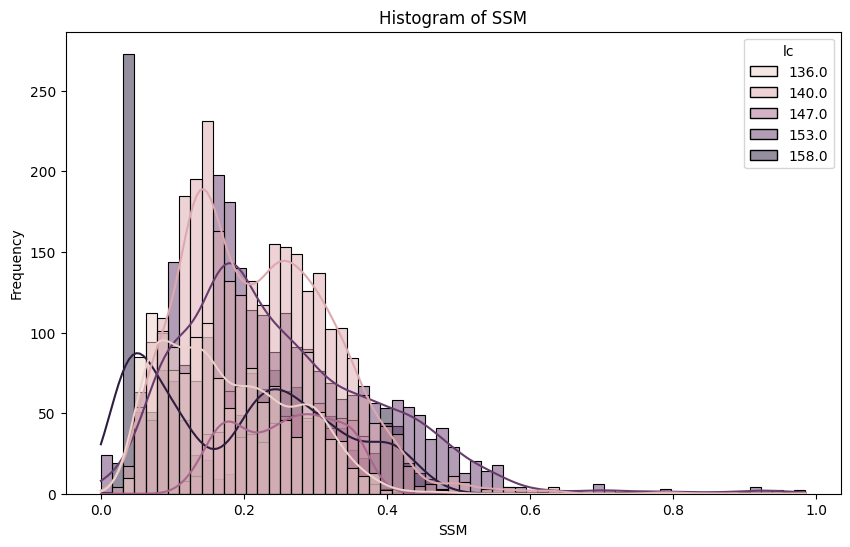

In [363]:
# prompt: plot histogram of SSM using sns

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'gp_merged' DataFrame is already created as in the provided code.

plt.figure(figsize=(10, 6))
sns.histplot(gp_merged, x='SSM', kde=True, hue='lc')
plt.title('Histogram of SSM')
plt.xlabel('SSM')
plt.ylabel('Frequency')
plt.show()


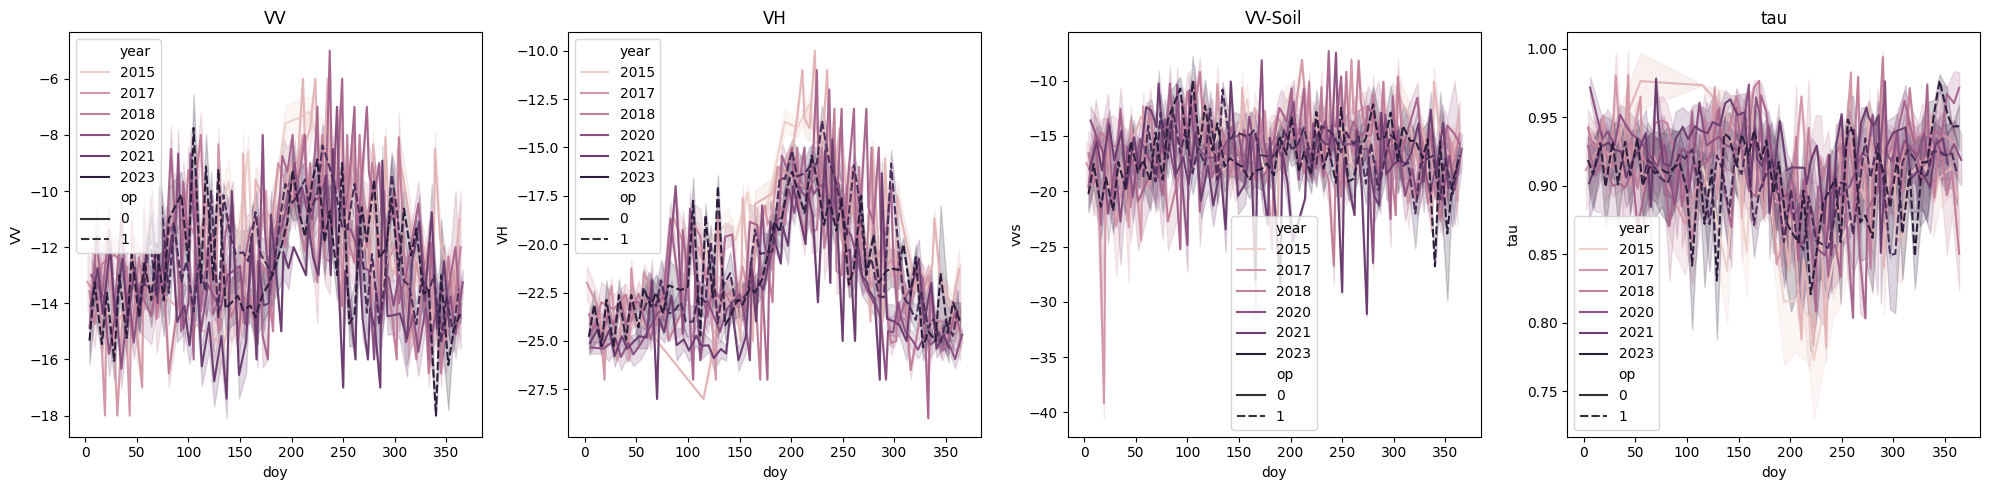

In [364]:
# prompt: plot VV, VH, rvi and SSM using seaborn lineplot in four subplots with four columns

# Assuming 'merged_df' is your DataFrame as defined in the previous code.

import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot VV
sns.lineplot(ax=axes[0], x='doy', y='VV', data=gp_merged, hue='year', style='op')
axes[0].set_title('VV')

# Plot VH
sns.lineplot(ax=axes[1], x='doy', y='VH', data=gp_merged, hue='year', style='op')
axes[1].set_title('VH')

# Plot rvi
sns.lineplot(ax=axes[2], x='doy', y='vvs', data=gp_merged, hue='year', style='op')
axes[2].set_title('VV-Soil')

# Plot SSM_asc
sns.lineplot(ax=axes[3], x='doy', y='tau', data=gp_merged, hue='year', style='op')
axes[3].set_title('tau')

plt.tight_layout()
plt.show()


In [365]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [410]:
# Train-Test Split
# X = gp_merged[['angle', 'vvs', 's', 'year', 'doy', 'lc', 'op']]
# y_reg = gp_merged['SSM']
X = gp_merged[['VH', 'VV', 'angle', 'rvi', 'year', 'doy', 'lc', 'op']]
y_reg = gp_merged['vvs']
# y_reg = gp_merged['s']
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6295, 8) (2698, 8) (6295,) (2698,)


In [411]:
# Initialize and train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=42)
rf_reg.fit(X_train, y_train)

# Make predictions
y_pred_reg = rf_reg.predict(X_test)
print(y_pred_reg)

[-29.32778066 -20.32514474 -15.64216013 ... -20.14543073 -14.33903542
 -15.80609287]


In [412]:
# from sklearn.experimental import enable_halving_search_cv  # noqa
# from sklearn.model_selection import HalvingGridSearchCV
# from scipy.stats import randint

# param_dist = {
#     "n_estimators": [10, 1000],
#     "max_depth": [10, 100],
#     "min_samples_split": [2, 9],
#     "min_samples_leaf": randint(1, 9)
# }
# rf_tree = RandomForestRegressor(random_state=42)
# # tree_cv = RandomizedSearchCV(rf_tree, param_dist, cv=5)
# # tree_cv.fit(X_train, y_train)

# param_grid = {"max_depth": [10, 50],
#               "min_samples_split": [5, 10]}
# search = HalvingGridSearchCV(rf_tree, param_grid, resource='n_estimators',
#                              max_resources=100,
#                              random_state=42).fit(X_train, y_train)
 
# print("Tuned Decision Tree Parameters: {}".format(search.best_params_))
# print("Best score is {}".format(search.best_score_))

In [413]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f"R^2: {rf_reg.score(X_test, y_test)}")

# Evaluate the Random Forest Regressor
mae_reg = mean_absolute_error(y_test, y_pred_reg)
print(f"MAE: {mae_reg}")


# calculate bias
bias= np.mean(y_test - y_pred_reg)
print(f"Bias: {bias}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
print(f"RMSE: {rmse}")

# Calculate unbiased RMSE (ubRMSE)
ubrmse = np.sqrt(rmse**2 - bias**2)
print(f"ubRMSE: {ubrmse}")


R^2: 0.8735653008658846
MAE: 0.8629260008027053
Bias: 0.0463984411735438
RMSE: 1.7594502638896468
ubRMSE: 1.7588383711296536


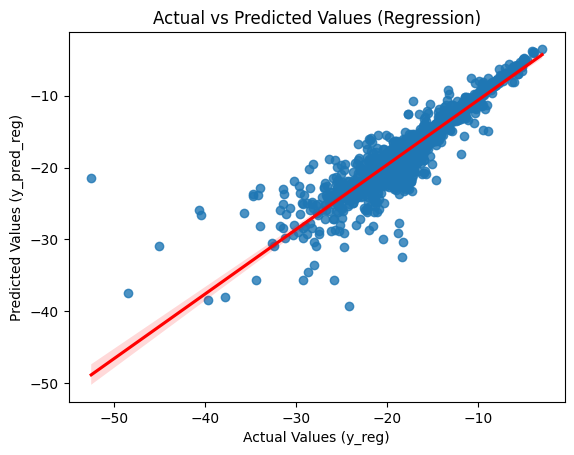

In [414]:
# prompt: plot y_pred_reg vs y_reg and add regression line using sns

# Plot y_pred_reg vs y_reg with regression line
sns.regplot(x=y_test, y=y_pred_reg, line_kws={"color": "red"})
plt.xlabel("Actual Values (y_reg)")
plt.ylabel("Predicted Values (y_pred_reg)")
plt.title("Actual vs Predicted Values (Regression)")
plt.show()

In [415]:
feature_names = list(X.columns)
feature_names

['VH', 'VV', 'angle', 'rvi', 'year', 'doy', 'lc', 'op']

In [416]:
import ee
import os
import geemap
import pandas as pd

from geemap import ml

In [417]:
# Check if the Earth Engine initialization has been performed.
if not ee.data._credentials:
  geemap.ee_initialize(project='ee-mortezakhazaei1370')
  print("Earth Engine initialized.")
else:
  print("Earth Engine already initialized.")

Earth Engine already initialized.


In [418]:
user_id = geemap.ee_user_id()
user_id = '/'.join(user_id.split('/')[:-1])
user_id

'projects/ee-mortezakhazaei1370/assets'

In [426]:
n_estimators = rf_reg.n_estimators
print(n_estimators)
mdepth = rf_reg.max_depth
print(mdepth)

var = 'vvs'
year_span = '2015to2023'

fname = f"ensemble_trees_wcm_{var}_param_withRVI_n{n_estimators}_md{mdepth}_{year_span}_RefineLEE_median_new_constant"
fname

10
20


'ensemble_trees_wcm_vvs_param_withRVI_n10_md20_2015to2023_RefineLEE_median_new_constant'

In [427]:
# specify asset id where to save trees
# be sure to change <user_name> to your ee user name
asset_id = '/'.join([user_id, fname])
asset_id

'projects/ee-mortezakhazaei1370/assets/ensemble_trees_wcm_vvs_param_withRVI_n10_md20_2015to2023_RefineLEE_median_new_constant'

In [428]:
# convert the estimator into a list of strings
# this function also works with the ensemble.ExtraTrees estimator
trees = ml.rf_to_strings(rf_reg, feature_names, processes=32, output_mode='REGRESSION')
len(trees)

10

In [429]:
import re

def clean_tree(tree):
    return re.sub(r'\s+', ' ', tree)  # Replace multiple spaces with a single space

In [430]:
cleaned_trees = [clean_tree(tree) for tree in trees]
len(cleaned_trees[0])

274962

In [431]:
# Convert tree strings to a FeatureCollection
dummy_geometry = ee.Geometry.Point([0, 0])  # Placeholder geometry
features = [ee.Feature(dummy_geometry, {"tree": tree.replace("\n", "#")}) for tree in cleaned_trees]
fc = ee.FeatureCollection(features)

In [432]:
# get export task and start
task = ee.batch.Export.table.toAsset(
    collection=fc, description=fname, assetId=asset_id
)
task.start()

In [563]:
ml.trees_to_csv(trees, fname + '.csv')

In [569]:
# pass list of ee.Strings to an ensemble decision tree classifier (i.e. RandomForest)
classifier = ee.Classifier.decisionTreeEnsemble(cleaned_trees)

# get export task and start
task = ee.batch.Export.classifier.toAsset(
    classifier=classifier, description=fname, assetId=asset_id
)
task.start()

In [363]:
# kick off an export process so it will be saved to the ee asset
export_trees_to_fc(trees, asset_id, description=fname)